In [341]:
# Load libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sys

%load_ext autoreload
%autoreload 2

# Import load_csv
from helpers import *
from utils import *
from implementations import *
from preprocess import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [286]:
# Dataset shape without using pandas
x_train, x_test, y_train, train_ids, test_ids = load_csv_data('data/dataset')

print("Train set shape : ", x_train.shape)
print("Test set shape : ", x_test.shape)
print("test_ids shape : ", test_ids.shape)
print(test_ids)

Train set shape :  (328135, 321)
Test set shape :  (109379, 321)
test_ids shape :  (109379,)
[328135 328136 328137 ... 437511 437512 437513]


## Data processing

In [92]:
count_rows_with_nan = np.sum(np.isnan(x_train).any(axis=1))
print("Number of rows containing at least one NaN in train set:", count_rows_with_nan)

count_columns_with_nan = np.sum(np.isnan(x_train).any(axis=0))
print("Number of columns containing at least one NaN in train set:", count_columns_with_nan)

count_rows_with_nan = np.sum(np.isnan(x_test).any(axis=1))
print("Number of rows containing at least one NaN in test set:", count_rows_with_nan)

count_columns_with_nan = np.sum(np.isnan(x_test).any(axis=0))
print("Number of columns containing at least one NaN in test set:", count_columns_with_nan)

Number of rows containing at least one NaN in train set: 328135
Number of columns containing at least one NaN in train set: 239
Number of rows containing at least one NaN in test set: 109379
Number of columns containing at least one NaN in test set: 232


All of the lines both in train set and test set contain at least one Nan. 

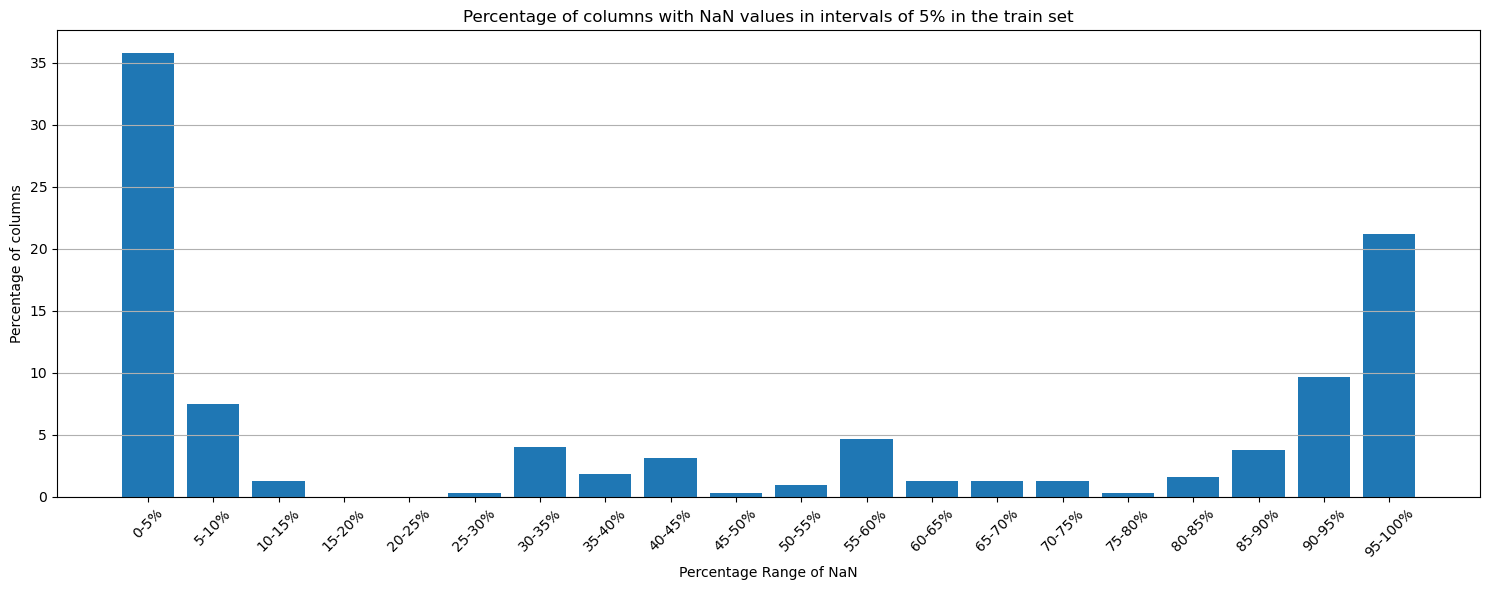

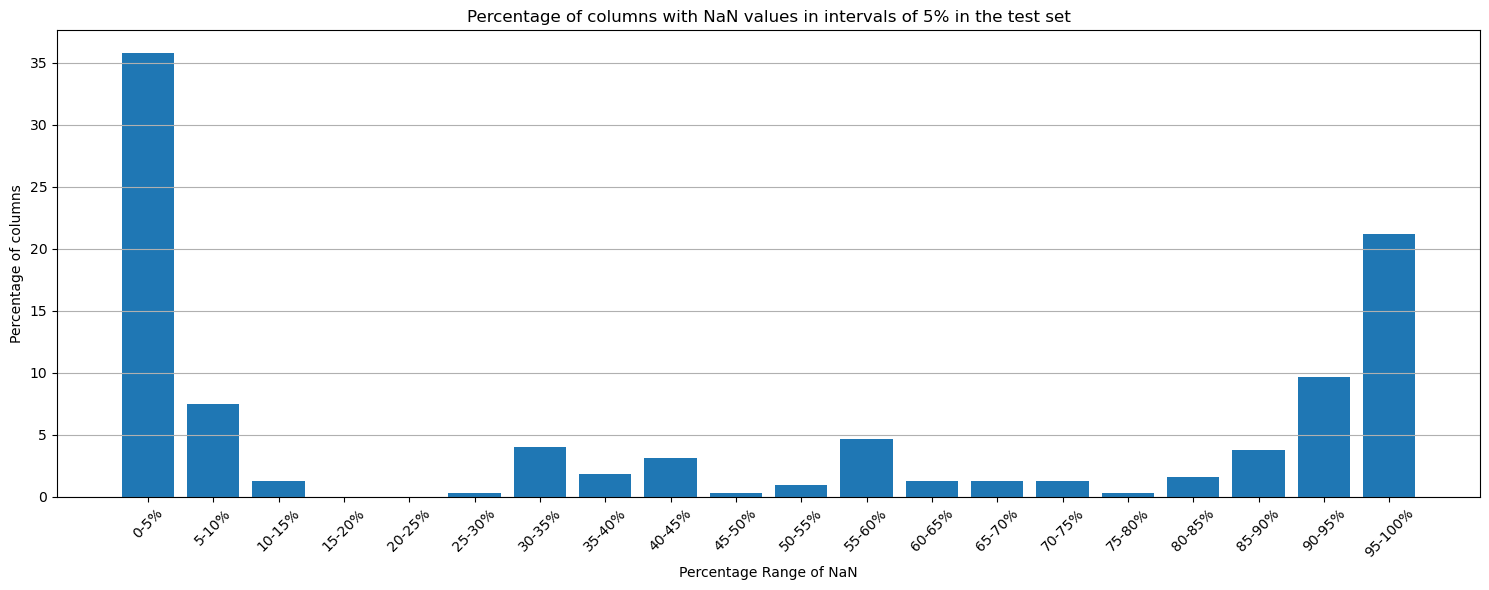

In [93]:
#Analyze the input
show_NaN_cols(x_train, "train set")
show_NaN_cols(x_test, "test set")

### Preprocess data 

In [390]:
# Training set

f_x, cols_excluded = filter_cols(x_train,97)
headers = load_csv_headers("data/dataset/x_train.csv")
features_removed = unused_features_indices(headers)
all_cols_excluded = np.unique(np.concatenate((np.array(features_removed), cols_excluded)))
T_x = np.delete(f_x, all_cols_excluded, axis=1)
T_x = build_log(T_x)
T_x = standardize(T_x)

# Test set


f_x_test, junk = filter_cols(x_test,97)  # junk because we do not need the cols_excluded, since we want to exclude the same columns as in the train set
T_x_test = np.delete(f_x_test, all_cols_excluded, axis=1)
T_x_test = build_log(T_x_test)
T_x_test = standardize(T_x_test)

In [95]:
# export the filtered data to csv
np.savetxt("data/filtered_dataset.csv", T_x, delimiter=",")

## PCA

In [300]:
covariance_matrix = np.cov(T_x, rowvar=False, dtype=np.float64)

eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

In [301]:
# check if the eingenvalues are complex

if np.any(np.iscomplex(eigenvalues)):
    print("Eigenvalues are complex")
else:
    print("Eigenvalues are real")

Eigenvalues are real


In [302]:
# Select the number of principal components (e.g., first two)
num_components = 2
selected_eigenvectors = eigenvectors[:, :num_components]
reduced_data = np.dot(T_x, selected_eigenvectors)


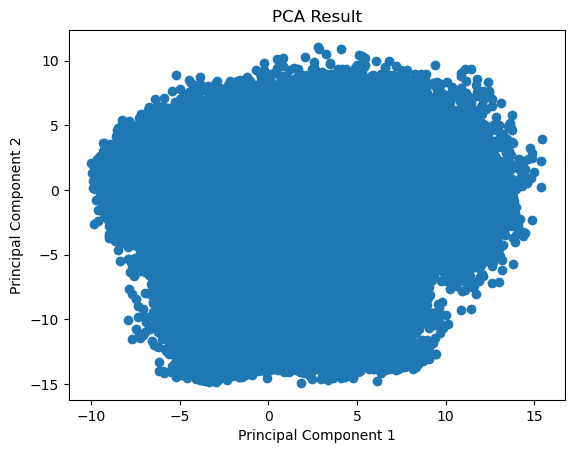

In [303]:
plt.scatter(reduced_data[:, 0], reduced_data[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')
plt.show()

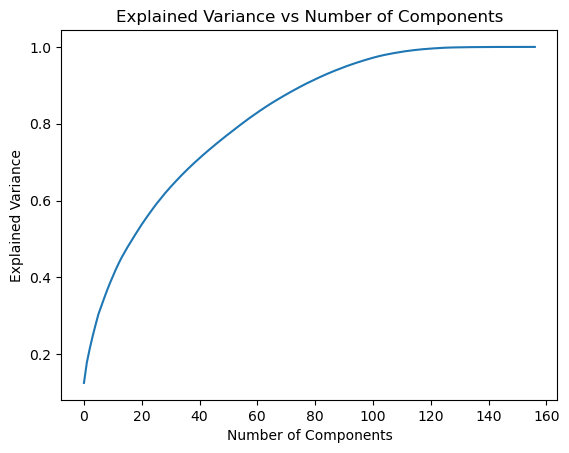

In [114]:
# Plot explained variance 
plt.plot(np.cumsum(eigenvalues) / np.sum(eigenvalues))
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.show()


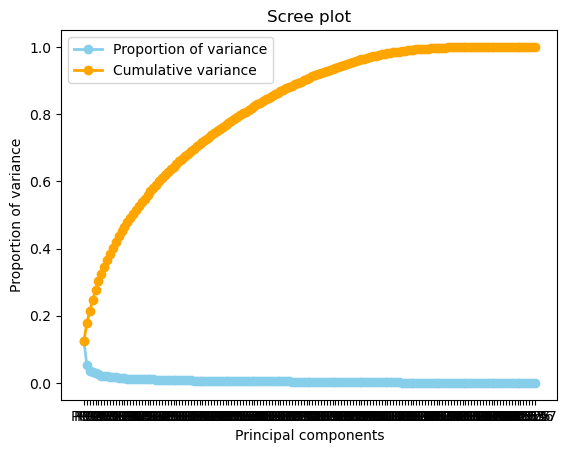

In [103]:
#1. Calculate the proportion of variance explained by each feature
eigenvalues[0] / np.sum(eigenvalues)
sum_eigenvalues = np.sum(eigenvalues)

prop_var = [i/sum_eigenvalues for i in eigenvalues]

#2. Calculate the cumulative variance
cum_var = [np.sum(prop_var[:i+1]) for i in range(len(prop_var))]


#3. Plot the results
x_labels = ['PC{}'.format(i+1) for i in range(len(prop_var))]

plt.plot(x_labels, prop_var, marker='o', markersize=6, color='skyblue', linewidth=2, label='Proportion of variance')
plt.plot(x_labels, cum_var, marker='o', color='orange', linewidth=2, label="Cumulative variance")
plt.legend()
plt.title('Scree plot')
plt.xlabel('Principal components')
plt.ylabel('Proportion of variance')
plt.show()

In [ ]:
# Number of features we can keep to explain 95% of the variance
num_components = np.where(np.array(cum_var) > 0.95)[0][0] + 1
print(num_components)

# Reduce the dimensionality of the data 
selected_eigenvectors = eigenvectors[:, :num_components]
reduced_data = np.dot(T_x, selected_eigenvectors)

## Predictions

In [378]:
# Split the data into train and test sets
x_training_full, x_validation_full, y_training_full, y_validation_full = split_data(T_x, y_train, 0.8)

x_training = x_training_full
x_validation = x_validation_full

# for y keep only labels column for training (drop indexes)
y_training = y_training_full[:, 1]
y_validation = y_validation_full[:, 1]

# Print all shapes

print("x_training shape : ", x_training.shape)
print("x_validation shape : ", x_validation.shape)
print("y_training shape : ", y_training.shape)
print("y_validation shape : ", y_validation.shape)

x_training shape :  (262508, 251)
x_validation shape :  (65627, 251)
y_training shape :  (262508,)
y_validation shape :  (65627,)


#### Logistic regression

In [387]:
import datetime

# perform classification using logistic regression

# Define the parameters of the algorithm.
max_iters = 13
gamma = 0.48

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = logistic_regression(y_training, x_training, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))

Gradient Descent: execution time = 0.975 seconds


In [388]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

f1score, precision = score(y_validation_pred, y_validation)
print("Validation F1 score: ", f1score)
print("Validation Precision: ", precision)

Training accuracy:  0.8764913831197525
Validation accuracy:  0.8764685266734729
Validation F1 score:  0.4062980593189308
Validation Precision:  0.3470970970970971


#### Reg Logistic Regression

In [369]:
# Use def reg_logistic_regression(y, tx, lambda_, initial_w, max_iters, gamma):
# to train the model with different lambdas

# Define the parameters of the algorithm.
max_iters = 13
gamma = 0.481
lambda_ = 0

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = reg_logistic_regression_v2(y_training, x_training, lambda_, w_initial, max_iters, gamma, threshold=1e-8)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))


Gradient Descent: execution time = 1.107 seconds


Training accuracy:  0.8764990019351792
Validation accuracy:  0.8764075761500602
loss :  0.5582300966105634
Validation F1 score:  0.406179076067062
Validation Precision:  0.3469234617308654
F1 score:  0.4108239741213245
Precision:  0.35640411174875447


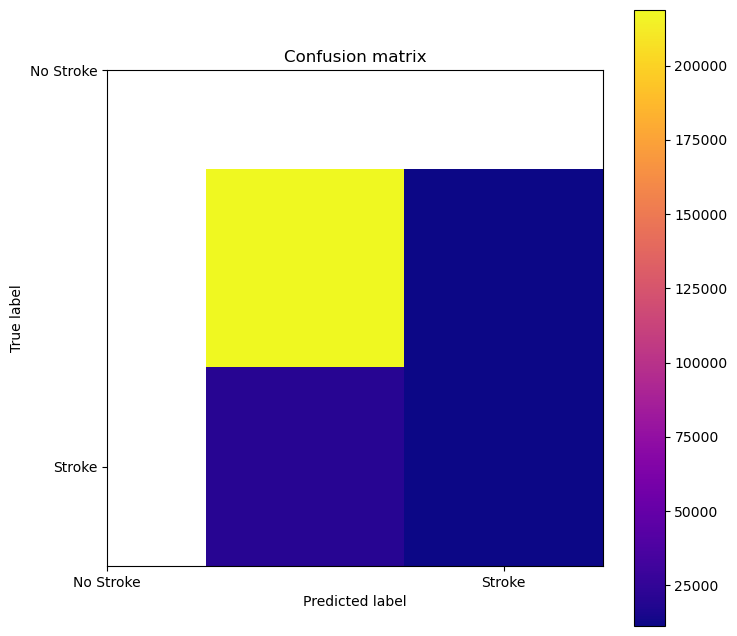

In [382]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

f1score, precision = score(y_validation_pred, y_validation)
print("Validation F1 score: ", f1score)
print("Validation Precision: ", precision)

plot_results(y_training_pred, y_training)

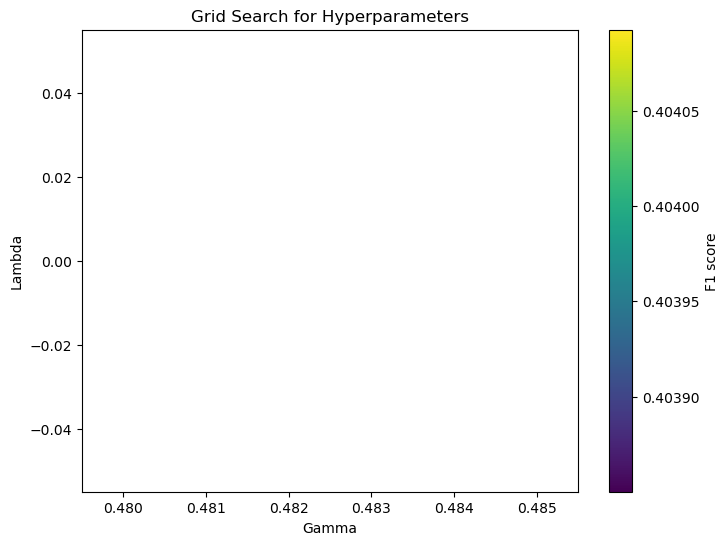

In [313]:
lambda_values = [0]
gamma_values = np.arange(0.48, 0.485, 0.001)

best_lambda, best_gamma, best_f1score = grid_search(lambda_values, gamma_values, y_training, x_training, y_validation, x_validation, max_iters=100)

In [314]:
print("best_lambda : ", best_lambda)
print("best_gamma : ", best_gamma)
print("best_f1score : ", best_f1score)

best_lambda :  0
best_gamma :  0.48
best_f1score :  0.40409241818551395


In [317]:
w, loss = cross_validation(x_training, y_training, 5, 0.483)


/Users/tatianahominal/Documents/MA1/MachineLearning/GroupProject/ml-project-1-stochastik/utils.py:324: RuntimeWarning: invalid value encountered in scalar divide
  precision = cm[1,1]/(cm[1,1] + cm[0,1])


## K-nearest Neighbor

In [111]:
# Create a k-NN classifier with k=2
knn = KNN(k=2)

# replace the labels that have -1 by 0
y_y_training = y_training.copy()
y_y_training[np.where(y_y_training == -1)] = 0

y_y_validation = y_validation.copy()
y_y_validation[np.where(y_y_validation == -1)] = 0

knn.fit(x_training, y_y_training)

# Make predictions on the test data
predictions = knn.predict(x_validation)
score(predictions, y_y_validation)

KeyboardInterrupt: 

## Submission

Dummy dataset

In [ ]:
# Check what are the values of y_train
print("y_train values : ", np.unique(y_train[:, 1]))

# Check y train shape
print("y_train shape : ", y_train[:, 1].shape)

# Get proportion of -1 and 1 in y_train
proportion_of_0 = np.sum(y_train[:, 1] == -1) / y_train[:, 1].shape[0]
print("Proportion of 0 in y_train : ", proportion_of_0)

# Shape of test set
print("Shape of test set : ", x_test.shape)
 
# Create an array of size 109379 that contain a proportion of 0 and 1 equal to the proportion of 0 and 1 in y_train
y_pred = np.random.choice([-1, 1], size=x_test.shape[0], p=[proportion_of_0, 1-proportion_of_0])

# Get proportion of -1 and 1 in y_test
proportion_of_0 = np.sum(y_pred == -1) / y_pred.shape[0]
print("Proportion of 0 in y_train : ", proportion_of_0)
print("y_test shape : ", y_pred.shape)

y_train values :  [-1  1]
y_train shape :  (328135,)
Proportion of 0 in y_train :  0.911697929205967
Shape of test set :  (109379, 321)
Proportion of 0 in y_train :  0.9113175289589409
y_test shape :  (109379,)


In [391]:
# Create a csv file with the predictions with best params
w_initial = np.zeros(x_training.shape[1])
w, loss = logistic_regression(y_training, x_training, w_initial, 13, 0.48)
aicrowd_submission(predict(w, T_x_test), "data/dataset/")